# What an EPI pays for the whole of k-space

[`01_build.ipynb`](01_build.ipynb) acquired 128 lines in 90 ms and asserted that `k` is exact at
every one of them. It could not say what that cost, because everything it costs is a property of
the magnetisation.

| | |
|---|---|
| **1. the one number that is EPI** | the readout bandwidth per pixel over the phase-encode bandwidth per pixel. It is **over a hundred** at this protocol — §1 prints it — and every artefact below is a consequence of it |
| **2. undoing ramp sampling** | the sampling question comes first and it is not about interpolation; then the operator, and the two failures a reader will actually hit |
| **3. off-resonance on one shot** | a shift along `ky`, a period-two modulation along `kx`, and the ghost that is |
| **4. the navigator correction** | two odd/even mismatches which are Fourier duals, and only one of them is here |
| **5. single shot against multi shot** | the same lines in the same number of shots, differing only in *which shot takes which* |
| **6. a brain, and what distortion looks like** | behind the switch |
| **7. GRAPPA** | judged twice, and the separately acquired calibration band priced against a self-calibration no real scan can have |
| **8. the transient** | why a four-shot EPI is not four single-shot EPIs — decomposed over three files that differ only in the magnetisation each shot is acquired from |

## This notebook measures on one voxel and illustrates on a brain

**Every *number* here is measured on a single-spin phantom.** A ghost is a period-two modulation
of `ky` and a distortion is a displacement, so both live in `S(k)`; the k-space of a *point*
object **is** that modulation, with no object structure on top of it. Same argument as
[`../fse_2d/02`](../fse_2d/02_simulate_and_reconstruct.ipynb), at a different period, and it is
what makes this notebook safe to run.

§6, §7 and §8 need an object and coils and are behind `BRAIN_IMAGES`. §7 in particular **cannot**
be measured on one spin: parallel imaging is a statement about receive sensitivity.

**Every ghost is quoted against its own `B0 = 0` control.** An EPI ghosts for half a dozen
reasons and they all look identical in the image, so a ghost reported without a control has
measured nothing.

**Needs `seqcraft[sim,recon]`** plus `pygrappa`, and the BrainWeb phantom
[`../gre_2d/02`](../gre_2d/02_simulate_and_reconstruct.ipynb) downloads into `examples/data/`.

In [1]:
import os

# Set before torch is imported, which is where it reads them.  MRzero's inner loop is dense complex
# linear algebra and it will take every core it is offered.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch
from scipy.interpolate import CubicSpline

import seqcraft as sc

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

#: Reconstruct the BrainWeb slab in sections 6 and 7.  Every *number* outside those two sections is
#: measured on one spin, so False costs pictures and the parallel-imaging measurement, nothing else.
BRAIN_IMAGES = True

#: Slices in the slab.  A phantom one voxel thick reads a slice-select gradient as complete
#: dephasing and returns exactly zero signal, so two is the minimum that has anything to dephase.
NZ = 2
#: Which of the phantom's 128 slices the slab is centred on -- 64, mid-brain, the same as every
#: other example, so the images here and there are of the same object.
Z_CENTER = 64
N_COILS = 8

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'gre_epi_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
NX, NY = MATRIX
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]
LINES = [int(v) for v in nominal['lines']]
DWELL_S = float(nominal['dwell_s'])
OVERSAMPLING = int(nominal['oversampling'])
ACS_LINES = int(nominal['acs_lines'])

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)


def readout(**kwargs):
    """The readout `01` built, re-created here.  `EPI2D` ships, so this is an import, not a copy."""
    return sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                            oversampling=OVERSAMPLING, **kwargs)


epi = readout()
assert np.allclose(epi.k_read_per_m, nominal['k_read_per_m'], atol=1e-9)
print(f'{epi.num_samples} samples at {epi.dwell_s * 1e9:.0f} ns, echo spacing '
      f'{epi.echo_spacing_s * 1e6:.0f} us')
print(f'k_read_per_m agrees with what 01 wrote to '
      f'{np.abs(epi.k_read_per_m - nominal["k_read_per_m"]).max():.1e} 1/m')
print()
print(f'{torch.get_num_threads()} simulation threads of {os.cpu_count()} cores.')
print(f'Budget: ~40 s of one-voxel measurement, and BRAIN_IMAGES = {BRAIN_IMAGES}'
      f'{" -- about 5 minutes of brain on top" if BRAIN_IMAGES else " -- no brain"}.')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


256 samples at 2500 ns, echo spacing 700 us
k_read_per_m agrees with what 01 wrote to 0.0e+00 1/m

4 simulation threads of 32 cores.
Budget: ~40 s of one-voxel measurement, and BRAIN_IMAGES = True -- about 5 minutes of brain on top.


---
## 1. The one number that is EPI

A Cartesian sequence acquires one `ky` line per excitation, so time along `ky` is TR and
off-resonance does nothing to the geometry. An EPI acquires them **one echo spacing apart**, and
that is the whole difference:

$$\frac{\text{readout bandwidth per pixel}}{\text{phase-encode bandwidth per pixel}}
  \;=\; \frac{1/(N_x\tau)}{1/(N_y\,\text{esp})}$$

Everything in §3 onwards is this ratio being large.

In [2]:
esp = epi.echo_spacing_s
pe_bandwidth = 1 / (NY * esp)
print(f'readout       {epi.bandwidth_hz_px:9.1f} Hz per pixel   '
      f'({epi.num_samples} samples x {epi.dwell_s * 1e9:.0f} ns = '
      f'{epi.num_samples * epi.dwell_s * 1e6:.0f} us)')
print(f'phase encode  {pe_bandwidth:9.1f} Hz per pixel   '
      f'({NY} echoes x {esp * 1e6:.0f} us = {NY * esp * 1e3:.2f} ms)')
print(f'ratio         {epi.bandwidth_hz_px / pe_bandwidth:9.0f}')
print()
print(f'So a {60:.0f} Hz offset moves the object {60 / pe_bandwidth:.2f} px along ky and '
      f'{60 / epi.bandwidth_hz_px:.3f} px along kx.')
print('The readout direction is effectively immune and the phase-encode direction is not, which is')
print('why an EPI distorts along ky and why shortening the *train* is the only thing that helps.')

readout          1562.5 Hz per pixel   (256 samples x 2500 ns = 640 us)
phase encode       11.2 Hz per pixel   (128 echoes x 700 us = 89.60 ms)
ratio               140

So a 60 Hz offset moves the object 5.38 px along ky and 0.038 px along kx.
The readout direction is effectively immune and the phase-encode direction is not, which is
why an EPI distorts along ky and why shortening the *train* is the only thing that helps.


---
## 2. Undoing ramp sampling, and why it is not a NUFFT

Ramp sampling makes the readout non-uniform in `k`, and the reflex is to reach for a non-Cartesian
reconstruction. **That is the wrong tool.** The non-uniformity here has three properties a general
trajectory does not:

1. it is **one-dimensional** — `ky` is constant across a readout, so nothing is scattered in 2D;
2. it is **the same for every readout**, up to a reversal, which is itself a fixed permutation;
3. it is **known before the scan runs** — it is `k_read_per_m`, computed at design time.

So the regridding is a **fixed linear operator**: one matrix, built once, applied with one matrix
multiply per polarity. None of a NUFFT's machinery has anything to act on — no oversampled
convolution grid, no Kaiser–Bessel kernel, no deapodization, no density compensation to estimate,
nothing to iterate.

### The structure is gadgetron's; the kernel inside it is scipy's

[`EPIReconXObjectTrapezoid`](https://github.com/gadgetron/gadgetron/blob/master/toolboxes/mri/epi/EPIReconXObjectTrapezoid.h)
gets the *shape* of the answer right — a matrix that does not depend on the data, built once,
applied per polarity, with the reversal folded in as a **column reversal** rather than an array
flip. What it fills that matrix with is a least-squares sinc, and §2.2 measures that against a
cubic spline. Interpolation is linear in the data for fixed knots, so applying scipy to the
identity gives the matrix that reproduces scipy exactly.

[pulseq's own `reconExample2DEPI.m`](https://github.com/pulseq/pulseq/blob/master/matlab/demoRecon/reconExample2DEPI.m)
is the simple end: one `interp1(..., 'spline')` per readout. Same kernel, applied one line at a
time.

In [3]:
class Regridder:
    """The fixed one-dimensional operator that undoes ramp sampling.

    `gap` is the number to look at before any question about interpolation: the largest spacing
    between adjacent samples, in units of the reconstruction `dk`.  Above 1 the readout does not
    sample the grid it is being regridded onto, and **no interpolator can fix that**.
    """

    def __init__(self, epi, *, method='spline', rcond=1e-3):
        self.method, self.epi = method, epi
        self.k = epi.k_read_per_m / epi.dk_read_per_m       # sample positions, in units of dk
        self.grid = np.arange(epi.matrix[0]) - epi.matrix[0] // 2
        self.gap = float(np.diff(self.k).max())
        # Partial echo leaves grid points nobody sampled.  Solving for them would be extrapolation
        # dressed as interpolation, so they stay exactly zero and the reconstruction fills them.
        self.covered = (self.grid >= self.k.min()) & (self.grid <= self.k.max())
        target = self.grid[self.covered]
        self.condition = float('nan')

        if method == 'spline':
            self.pos = CubicSpline(self.k, np.eye(self.k.size), axis=0)(target)
        elif method == 'sinc':
            forward = np.sinc(self.k[:, None] - target[None, :])
            self.pos = np.linalg.pinv(forward, rcond=rcond)
            self.condition = float(np.linalg.cond(forward))
        elif method != 'linear':
            raise sc.ConfigurationError(f'unknown regridding method {method!r}.')
        # A reverse lobe's sample i sits at k[N-1-i], so reversing its samples puts them back on
        # exactly the forward positions -- which makes its operator the forward one with its
        # columns reversed.  One matrix, two polarities.
        self.neg = None if method == 'linear' else self.pos[:, ::-1]

    def __call__(self, readouts, reversed_flags):
        """``(lines, samples)`` in, ``(lines, nx)`` on the uniform grid out."""
        out = np.zeros((len(readouts), self.epi.matrix[0]), dtype=np.complex64)
        back = np.asarray(reversed_flags, dtype=bool)
        if self.method == 'linear':
            target = self.grid[self.covered]
            rows = np.where(back[:, None], readouts[:, ::-1], readouts)
            for i, row in enumerate(rows):
                out[i, self.covered] = (np.interp(target, self.k, row.real)
                                        + 1j * np.interp(target, self.k, row.imag))
            return out
        # Two matrix multiplies for the whole acquisition, not one per readout.
        if (~back).any():
            out[np.ix_(~back, self.covered)] = readouts[~back] @ self.pos.T
        if back.any():
            out[np.ix_(back, self.covered)] = readouts[back] @ self.neg.T
        return out


def regrid(signal, epi, reversed_flags, method='spline'):
    """Regrid with an operator built once per (readout, method) and cached on the readout."""
    cache = epi.__dict__.setdefault('_regridders', {})
    if method not in cache:
        cache[method] = Regridder(epi, method=method)
    return cache[method](signal, reversed_flags), cache[method].covered


def reversed_flags(epi, lines, *, navigators=False):
    """One flag per readout the file will contain, in order -- navigators first if there are any."""
    start = -epi.navigator_echoes if navigators else 0
    return [epi.polarity(e) < 0 for e in range(start, len(lines))]


def fftx(rows):
    """Readout k-space to hybrid (x, ky), which is where a Nyquist correction is applied."""
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(rows, axes=-1), axis=-1, norm='ortho'),
                           axes=-1)


def ifftx(rows):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rows, axes=-1), axis=-1, norm='ortho'),
                           axes=-1)


def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


print(f'{"os":>3s} {"samples":>8s} {"dwell":>8s} {"worst gap":>11s}  {"grid support"}')
for factor in (1, 2, 4):
    made = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX,
                            bandwidth_hz_px=epi.bandwidth_hz_px, oversampling=factor)
    operator = Regridder(made)
    print(f'{factor:3d} {made.num_samples:8d} {made.dwell_s * 1e9:7.0f}n {operator.gap:10.3f}dk  '
          f'{"under-sampled" if operator.gap > 1 else "adequate"}')

 os  samples    dwell   worst gap  grid support
  1      128    5000n      1.156dk  under-sampled
  2      256    2500n      0.578dk  adequate
  4      512    1500n      0.270dk  adequate


### 2.1 The sampling question comes before the interpolation question

The `worst gap` column above is the whole section. Ramp sampling makes the sample spacing vary —
dense on the ramps where the gradient is small, sparse on the flat top where it is large — and at
`oversampling=1` the sparse part reaches **above one Δk**. The flat top of a ramp-sampled lobe is
**under-sampled against the grid it is being regridded onto**, so the data do not support that
grid and *no interpolator can recover what was never measured*.

That is a **sampling-theory** reason to oversample the readout, not a numerical one — and
[`01`](01_build.ipynb) §3 measured that it is free.

### 2.2 Which operator, measured against exact k-space

Synthetic on purpose: a known object, its k-space evaluated **exactly** at the ramp-sampled
positions by direct summation, regridded, compared against its exact uniform k-space. No simulator
in the way, so nothing but the operator is being measured.

Two objects, because they ask different questions. Sinc interpolation *assumes* the signal is
band-limited to the reconstruction grid, so an object with hard edges is a test it is entitled to
lose and a strictly band-limited one is the test it is entitled to win.

In [4]:
rng = np.random.default_rng(3)
edges = np.zeros(NX, dtype=complex)
edges[20:30] = 1.0
edges[36:40] = 0.6
edges += 0.3 * np.exp(-((np.arange(NX) - 40.0) ** 2) / 30.0)
edges *= np.exp(1j * 0.4 * np.arange(NX) / NX)
spectrum = rng.standard_normal(NX) + 1j * rng.standard_normal(NX)
spectrum *= np.exp(-((np.arange(NX) - NX // 2) / (NX / 3.0)) ** 2)
OBJECTS = {'hard edges': edges,
           'band-limited': np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(spectrum)))}
X = (np.arange(NX) - NX // 2) / NX


def exact_kspace(image, k_in_dk):
    """What a receiver sampling at `k_in_dk` would record from `image`.  A sum, not an FFT."""
    return np.exp(-2j * np.pi * k_in_dk[:, None] * X[None, :]) @ image


print(f'{"os":>3s} {"samples":>8s} {"worst gap":>10s} {"object":>13s} {"np.interp":>10s} '
      f'{"spline":>9s} {"sinc pinv":>10s} {"cond(Q)":>9s}')
scores = {}
for factor in (1, 2, 4):
    made = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX,
                            bandwidth_hz_px=epi.bandwidth_hz_px, oversampling=factor)
    operator, truthful = Regridder(made), Regridder(made, method='sinc')
    for label, image in OBJECTS.items():
        truth = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(image)))
        measured = exact_kspace(image, made.k_read_per_m / made.dk_read_per_m)[None, :]
        errs = []
        for method in ('linear', 'spline', 'sinc'):
            got, covered = regrid(measured, made, [False], method=method)
            errs.append(np.linalg.norm(got[0][covered] - truth[covered])
                        / np.linalg.norm(truth[covered]))
        scores[factor, label] = dict(zip(('linear', 'spline', 'sinc'), errs))
        print(f'{factor:3d} {made.num_samples:8d} {operator.gap:9.3f}'
              f'{" " if operator.gap <= 1 else "!"} {label:>13s} '
              f'{errs[0]:10.5f} {errs[1]:9.5f} {errs[2]:10.5f} {truthful.condition:9.1e}')

print('\nThe "!" rows are section 2.1: every method fails there, including the good ones -- the')
print(f'band-limited object comes back at {scores[1, "band-limited"]["spline"]:.2f} even for a '
      f'cubic spline, because the data do not')
print('support the grid.  Once the sampling is adequate the spline wins on both objects, including')
print('the band-limited one the least-squares sinc is supposed to be optimal for -- at '
      f'oversampling 2, {scores[2, "band-limited"]["spline"]:.4f} against '
      f'{scores[2, "band-limited"]["sinc"]:.4f}.')
print('So the interpolator is scipy\'s, and it is not written here.')

 os  samples  worst gap        object  np.interp    spline  sinc pinv   cond(Q)
  1      128     1.156!    hard edges    0.34782   0.12340    0.22064   6.7e+14
  1      128     1.156!  band-limited    0.48556   0.45791    0.73707   6.7e+14
  2      256     0.578     hard edges    0.10104   0.00354    0.00146   1.9e+00
  2      256     0.578   band-limited    0.13647   0.01363    0.02836   1.9e+00


  4      512     0.270     hard edges    0.02256   0.00013    0.00142   1.8e+00


  4      512     0.270   band-limited    0.03177   0.00039    0.03593   1.8e+00

The "!" rows are section 2.1: every method fails there, including the good ones -- the
band-limited object comes back at 0.46 even for a cubic spline, because the data do not
support the grid.  Once the sampling is adequate the spline wins on both objects, including
the band-limited one the least-squares sinc is supposed to be optimal for -- at oversampling 2, 0.0136 against 0.0284.
So the interpolator is scipy's, and it is not written here.


### 2.3 The matrix *is* scipy, and that is the point

Materialising the spline as a matrix does not approximate scipy — it reproduces it to floating
point. What it buys is that the operator no longer depends on the data.

In [5]:
operator = Regridder(epi)
target = operator.grid[operator.covered]
data = (rng.standard_normal((N_COILS * NY, epi.num_samples))
        + 1j * rng.standard_normal((N_COILS * NY, epi.num_samples)))


def scipy_direct(rows):
    return (CubicSpline(operator.k, rows.real, axis=-1)(target)
            + 1j * CubicSpline(operator.k, rows.imag, axis=-1)(target))


began = time.perf_counter()
for _ in range(20):
    as_matrix = data @ operator.pos.T
matrix_ms = (time.perf_counter() - began) / 20 * 1e3
began = time.perf_counter()
for _ in range(20):
    direct = scipy_direct(data)
direct_ms = (time.perf_counter() - began) / 20 * 1e3
began = time.perf_counter()
Regridder(epi)
build_ms = (time.perf_counter() - began) * 1e3

print(f'the two agree to {np.abs(as_matrix - direct).max():.1e}')
print(f'{N_COILS} coils x {NY} lines: {matrix_ms:.2f} ms as a matrix against {direct_ms:.2f} ms '
      f'calling scipy,')
print(f'and the matrix is built once in {build_ms:.2f} ms.')
print('On one slice that is nothing; on an fMRI series it is the whole difference.')

the two agree to 3.3e-15
8 coils x 128 lines: 2.01 ms as a matrix against 34.61 ms calling scipy,
and the matrix is built once in 3.05 ms.
On one slice that is nothing; on an fMRI series it is the whole difference.


### 2.4 The two failures a reader will actually hit

Both on exact k-space again, so the reconstruction is the only thing under test. The object is
deliberately **off-centre**, because a mirror about the origin is invisible on a symmetric one —
which is the same trap [`../se_2d/01`](../se_2d/01_build.ipynb) names for k-space *extent* checks.

| | what it is | what it looks like |
|---|---|---|
| **forgetting to reverse** | the reverse lobe's samples left in acquisition order | a **mirrored** replica: the forward echoes are right and the reverse ones are flipped about `x = 0` |
| **skipping the regridding** | the samples treated as if uniform | a compression and a blur, **identical in both polarities** and therefore *not* a ghost |

The second is the interesting one, because it is the one a reader expects to ghost. It does not:
it is the same error on every echo, so it survives the `ky` transform untouched.

In [6]:
off_centre = np.zeros(NX, dtype=complex)
off_centre[18:26] = 1.0
off_centre[34:38] = 0.55
truth_profile = np.abs(off_centre)
k_in_dk = epi.k_read_per_m / epi.dk_read_per_m
forward = exact_kspace(off_centre, k_in_dk)
rows = np.stack([forward, forward[::-1]])          # what the two polarities actually record
crop = (epi.num_samples - NX) // 2

VARIANTS = {
    'correct': regrid(rows, epi, [False, True])[0],
    'forgot to reverse': regrid(rows, epi, [False, False])[0],
    # Reversed correctly and then cropped to nx as if the samples were uniform, which is the
    # mistake: the reversal is the easy half and the non-uniformity is the half that is invisible.
    'skipped the regridding': np.stack([forward[crop:crop + NX],
                                        rows[1][::-1][crop:crop + NX]]),
}


def profile(recovered):
    return np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(recovered))))


print(f'{"variant":24s} {"echo":>8s} {"centroid":>9s} {"width":>6s} {"error":>8s}')
for label, recovered in VARIANTS.items():
    for index, name in ((0, 'forward'), (1, 'reverse')):
        got = profile(recovered[index])
        centroid = float((got * (np.arange(NX) - NX // 2)).sum() / got.sum())
        width = int((got > 0.5 * got.max()).sum())
        err = np.linalg.norm(got - truth_profile) / np.linalg.norm(truth_profile)
        print(f'{label if index == 0 else "":24s} {name:>8s} {centroid:9.2f} {width:6d} '
              f'{err:8.4f}')

print('\nForgetting to reverse leaves the forward echo untouched and mirrors the reverse one about')
print('x = 0 -- the two disagree, and in a full acquisition that disagreement alternates with ky,')
print('which is exactly an N/2 replica.  Skipping the regridding is wrong by the same amount on')
print('both, so it is a geometric error rather than a ghost: the object comes back narrower and')
print('closer to the centre than it is.')

variant                      echo  centroid  width    error
correct                   forward    -39.19     12   0.0051
                          reverse    -39.19     12   0.0051
forgot to reverse         forward    -39.19     12   0.0051
                          reverse     39.19     12   1.4115
skipped the regridding    forward    -21.89      5   1.5844
                          reverse    -21.89      5   1.5844

Forgetting to reverse leaves the forward echo untouched and mirrors the reverse one about
x = 0 -- the two disagree, and in a full acquisition that disagreement alternates with ky,
which is exactly an N/2 replica.  Skipping the regridding is wrong by the same amount on
both, so it is a geometric error rather than a ghost: the object comes back narrower and
closer to the centre than it is.


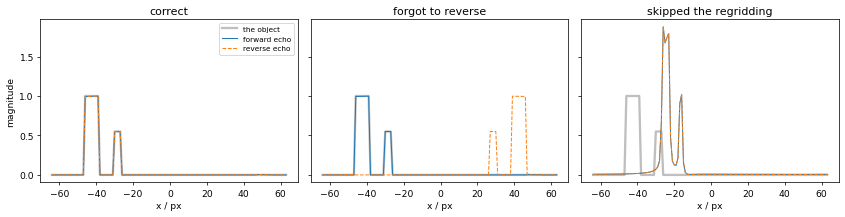

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.4), sharey=True)
for ax, (label, recovered) in zip(axes, VARIANTS.items()):
    ax.plot(np.arange(NX) - NX // 2, truth_profile, color='0.75', lw=2.5, label='the object')
    ax.plot(np.arange(NX) - NX // 2, profile(recovered[0]), lw=1.1, label='forward echo')
    ax.plot(np.arange(NX) - NX // 2, profile(recovered[1]), lw=1.1, ls='--', label='reverse echo')
    ax.set(xlabel='x / px', title=label)
axes[0].set(ylabel='magnitude')
axes[0].legend(fontsize=8)
fig.tight_layout()

---
## 3. Off-resonance on a single shot

From here on the sequences are the **files [`01`](01_build.ipynb) wrote**, read back through
MRzero's own parser — never the tree. A `.seq` is what a scanner is given, and the trajectory the
simulator builds from one is not the arithmetic that produced it.

The `B0 = 0` row is the control, and it is the row that matters most: an EPI ghosts for half a
dozen reasons and they all look identical.

In [8]:
def spin(offset_hz, *, t1_s=1.0, t2_s=0.1, t2dash_s=0.05):
    """One spin at isocentre, at a given field offset."""
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=FOV_MM[0] / NX / 1e3, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0 + float(offset_hz)
    built.B1 = built.B1.float() * 0 + 1.0
    return built


def simulate(name, phantom, *, states=64):
    """Play one of `01`'s files and hand back the raw ADC signal, `(readouts, samples, coils)`."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq'))
    graph = mr0.compute_graph(imported, phantom, max_state_count=states, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, phantom, print_progress=False))
    del graph
    return signal.reshape(-1, epi.num_samples, signal.shape[-1])


def place(rows, lines, *, coils=False):
    """Put regridded readouts on the Cartesian grid by their line, zeros where nothing was taken."""
    grid = np.zeros(((rows.shape[0],) if coils else ()) + (NY, NX), dtype=np.complex64)
    grid[..., list(lines), :] = rows
    return grid


def ghost_ratio(image, half=None):
    """Energy one replica distance from the object, relative to the object's own row.

    Summed across the readout direction rather than read off one pixel: the N/2 replica of a point
    at isocentre is **antisymmetric in x**, so a single-pixel metric reads the zero crossing of the
    thing being measured and reports a ghost that goes *down* as the off-resonance goes up.
    """
    half = image.shape[0] // 2 if half is None else half
    peak = int(np.argmax(image.sum(axis=1)))
    return float(image[(peak + half) % image.shape[0]].sum() / image[peak].sum())


def odd_even_phase(epi, raw, echoes, *, skip=0):
    """The phase difference between the two readout polarities, per kx sample."""
    ordered = np.array([row[::-1] if epi.polarity(i) < 0 else row
                        for i, row in enumerate(raw[skip:skip + echoes])])
    even, odd = ordered[0::2], ordered[1::2]
    n = min(len(even), len(odd))
    return np.angle(np.mean(even[:n] * np.conj(odd[:n]), axis=0))


# 30 to 120 Hz rather than up to 300: at 128 lines and this echo spacing a 300 Hz offset makes a
# ghost as bright as the object, and the peak-finding metric below then measures the *ghost* and
# reports a negative shift.  That is a limit of the metric, not of the sequence -- and choosing
# offsets it can read is better than printing a number that quietly changed what it measured.
OFFSETS = (0.0, 30.0, 60.0, 120.0)
flags = reversed_flags(epi, LINES)
single = {}
print(f'{"B0":>7s} {"shift, px":>10s} {"predicted":>10s} {"odd/even, rad":>14s} '
      f'{"ghost / object":>15s}')
for offset_hz in OFFSETS:
    raw = simulate('gre_epi_single', spin(offset_hz))[:, :, 0]
    gridded, _ = regrid(raw, epi, flags)
    image = np.abs(ifft2c(place(gridded, LINES)))
    single[offset_hz] = image
    peak = int(np.argmax(image.sum(axis=1)))
    ramp = np.unwrap(odd_even_phase(epi, raw, NY))
    print(f'{offset_hz:6.0f}Hz {peak - NY // 2:10d} {offset_hz * NY * esp:10.2f} '
          f'{np.ptp(ramp):14.4f} {ghost_ratio(image):15.4f}')

print(f'\nTwo mechanisms, and the {epi.bandwidth_hz_px / pe_bandwidth:.0f} from section 1 is the '
      f'ratio between them.')
print('  Along the phase encode, off-resonance is a *shift*, predicted exactly by df * Ny * esp.')
print('  Along the readout, the same offset displaces each lobe by df / (gamma G) in *opposite*')
print('  directions on the two polarities -- a period-two modulation of ky, so an N/2 replica.')

     B0  shift, px  predicted  odd/even, rad  ghost / object


     0Hz          0       0.00         0.0000          0.0238


    30Hz          3       2.69         0.2403          0.1192


    60Hz          5       5.38         0.4807          0.2285


   120Hz         11      10.75         0.9613          0.4429

Two mechanisms, and the 140 from section 1 is the ratio between them.
  Along the phase encode, off-resonance is a *shift*, predicted exactly by df * Ny * esp.
  Along the readout, the same offset displaces each lobe by df / (gamma G) in *opposite*
  directions on the two polarities -- a period-two modulation of ky, so an N/2 replica.


---
## 4. The navigator correction — and which phase it is

`gre_epi_nav.seq` plays three un-encoded echoes before the imaging train. There are **two**
odd/even mismatches, they are Fourier duals, and they need opposite corrections:

| mismatch | what makes it | its signature | fit it as |
|---|---|---|---|
| the sample sits at `k + δk` | a gradient delay, an eddy current, a receive-filter delay | a linear phase in **x** | a ramp across **x**, in hybrid space |
| the object sits at `x + δx` | **off-resonance** — the sample at a given `kx` is acquired at a time that runs one way on a forward lobe and the other on a reverse one | a linear phase in **kx** | a ramp across **kx**, in k-space |

Both gadgetron's `EPICorrGadget` and pulseq's `reconExample2DEPI.m` fit the **first**, split evenly
between the polarities as `exp(∓iφ/2)`. That is right on a scanner, because a gradient delay is a
hardware constant a navigator can hold.

**A `.seq` carries no gradient delay** — the simulator plays what the file says — so here the `x`
ramp is not there to find and the `kx` ramp is. Both are computed below, so the one that does
nothing is visible beside the one that works.

Note also what the navigators do to the *sequence*: three of them leave the imaging train starting
on a **reverse** lobe, which nothing outside the module could arrange. `polarity` counts across
the whole train, and negative indices are the navigators.

In [9]:
def nyquist_phase(navigators, polarities):
    """The odd/even phase difference `a + b·u`, fitted from navigator echoes.

    Magnitude-weighted, because the phase of a sample with no signal in it is noise, and the slope
    comes from neighbouring products rather than from an unwrap, so it needs no branch cuts.
    """
    difference = (navigators[polarities > 0].mean(axis=0)
                  * np.conj(navigators[polarities < 0].mean(axis=0)))
    u = np.arange(difference.size) - difference.size // 2
    slope = float(np.angle(np.sum(difference[1:] * np.conj(difference[:-1]))))
    constant = float(np.angle(np.sum(difference * np.exp(-1j * slope * u))))
    return constant + slope * u


def apply_nyquist_phase(rows, flags, phi):
    """Split the correction evenly between the two polarities."""
    return rows * np.exp(1j * np.where(np.asarray(flags), 0.5, -0.5)[:, None] * phi[None, :])


nav_epi = readout(navigator_echoes=3)
NAV = nav_epi.navigator_echoes
nav_flags = reversed_flags(nav_epi, LINES, navigators=True)
nav_polarity = np.array([nav_epi.polarity(e) for e in range(-NAV, 0)])

print(f'polarity across the whole train  {[nav_epi.polarity(e) for e in range(-NAV, 4)]}')
print('  the three navigators, then imaging echo 0 -- which is a *reverse* lobe because three')
print(f'  navigators preceded it.  polarity(0) = {nav_epi.polarity(0):+d}.')
print()
print(f'{"B0":>7s} {"ramp in kx":>12s} {"ramp in x":>11s} {"ghost, raw":>11s} '
      f'{"after kx fit":>13s} {"after x fit":>12s}')
navigated = {}
for offset_hz in OFFSETS:
    raw = simulate('gre_epi_nav', spin(offset_hz))[:, :, 0]
    gridded, _ = regrid(raw, nav_epi, nav_flags)
    phi_k = nyquist_phase(gridded[:NAV], nav_polarity)
    phi_x = nyquist_phase(fftx(gridded[:NAV]), nav_polarity)
    got = {}
    for label, phi, in_hybrid in (('raw', None, False), ('kx', phi_k, False),
                                  ('x', phi_x, True)):
        body = gridded[NAV:]
        if phi is not None:
            body = (ifftx(apply_nyquist_phase(fftx(body), nav_flags[NAV:], phi)) if in_hybrid
                    else apply_nyquist_phase(body, nav_flags[NAV:], phi))
        got[label] = np.abs(ifft2c(place(body, LINES)))
    navigated[offset_hz] = got
    print(f'{offset_hz:6.0f}Hz {np.ptp(phi_k):12.4f} {np.ptp(phi_x):11.4f} '
          f'{ghost_ratio(got["raw"]):11.4f} {ghost_ratio(got["kx"]):13.4f} '
          f'{ghost_ratio(got["x"]):12.4f}')

print('\nThe kx fit returns the ghost to its B0 = 0 baseline at every offset -- that is the whole')
print('of the correction.  The x fit does almost nothing, which is the point of printing it: a')
print('.seq carries no gradient delay, so there is nothing in this file for that fit to find.')
print('Its column is not zero, though, and the reason is worth knowing before trusting it on a')
print('scanner: on a *point* object there is one x position with signal, so the fit is reading')
print("the sinc sidelobes of a single voxel.  It is measuring the object's own point spread and")
print('calling it a hardware term.')
print()
print('**A ghost can be measured on one spin; a ghost correction cannot be estimated from one.**')
print('And the caveat that stops this being sold as a fix: the kx term is only global when the')
print('field is.  Over a real head it is not, and removing it is a field map\'s job.')

polarity across the whole train  [1, -1, 1, -1, 1, -1, 1]
  the three navigators, then imaging echo 0 -- which is a *reverse* lobe because three
  navigators preceded it.  polarity(0) = -1.

     B0   ramp in kx   ramp in x  ghost, raw  after kx fit  after x fit


     0Hz       0.0000      7.5553      0.0240        0.0240       0.0130


    30Hz       0.2162      7.7587      0.1191        0.0261       0.0956


    60Hz       0.4325      8.4482      0.2287        0.0321       0.1785


   120Hz       0.8650     13.3969      0.4424        0.0375       0.3215

The kx fit returns the ghost to its B0 = 0 baseline at every offset -- that is the whole
of the correction.  The x fit does almost nothing, which is the point of printing it: a
.seq carries no gradient delay, so there is nothing in this file for that fit to find.
Its column is not zero, though, and the reason is worth knowing before trusting it on a
scanner: on a *point* object there is one x position with signal, so the fit is reading
the sinc sidelobes of a single voxel.  It is measuring the object's own point spread and
calling it a hardware term.

**A ghost can be measured on one spin; a ghost correction cannot be estimated from one.**
And the caveat that stops this being sold as a fix: the kx term is only global when the
field is.  Over a real head it is not, and removing it is a field map's job.


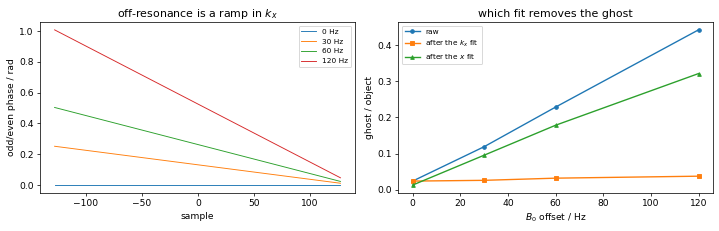

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6))
for offset_hz in OFFSETS:
    raw = simulate('gre_epi_single', spin(offset_hz))[:, :, 0]
    axes[0].plot(np.arange(epi.num_samples) - epi.num_samples // 2,
                 np.unwrap(odd_even_phase(epi, raw, NY)), lw=1.0, label=f'{offset_hz:.0f} Hz')
axes[0].set(xlabel='sample', ylabel='odd/even phase / rad',
            title='off-resonance is a ramp in $k_x$')
axes[0].legend(fontsize=8)
axes[1].plot(OFFSETS, [ghost_ratio(navigated[f]['raw']) for f in OFFSETS], 'o-', ms=4,
             label='raw')
axes[1].plot(OFFSETS, [ghost_ratio(navigated[f]['kx']) for f in OFFSETS], 's-', ms=4,
             label='after the $k_x$ fit')
axes[1].plot(OFFSETS, [ghost_ratio(navigated[f]['x']) for f in OFFSETS], '^-', ms=4,
             label='after the $x$ fit')
axes[1].set(xlabel='$B_0$ offset / Hz', ylabel='ghost / object',
            title='which fit removes the ghost')
axes[1].legend(fontsize=8)
fig.tight_layout()

---
## 5. Single shot against multi shot — and the ordering

`gre_epi_4shot.seq` and `gre_epi_blocked.seq` acquire the **same 64 lines in the same four shots**
and differ only in *which shot takes which*. That is the whole experiment.

The phase at line $k_y$ is $2\pi\Delta f(\mathrm{TE} + n\,\mathrm{esp})$ with $n$ the echo index.
Under **interleaving** $n = (k_y - s)/S$, so

$$\varphi(k_y) = 2\pi\Delta f\,\mathrm{TE}
  + \underbrace{\frac{2\pi\Delta f\,\mathrm{esp}}{S}k_y}_{\text{a shift, } S\times \text{ smaller}}
  \;-\; \underbrace{\frac{2\pi\Delta f\,\mathrm{esp}}{S}(k_y \bmod S)}_{\text{a sawtooth of period } S}.$$

Multi-shot buys a factor $S$ off the distortion and pays a **sawtooth** for it. A **blocked**
table's sawtooth has period $L = N_y/S$ with $L$ echo spacings of phase across it instead of $S$ —
sixteen instead of four.

**Both files are acquired in a steady state**, at the same TR, flip and echo time as everything
else here, after a two-shot run-in and with RF spoiling — §8 measures what that is worth.
Without it the shots differ from one another for reasons that have nothing to do with the
ordering, and the `B0 = 0` control column below is where that would show up.

In [11]:
SHOT_PLANS = {
    'interleaved, blip 4': ('gre_epi_4shot', [list(range(s, NY, 4)) for s in range(4)],
                            float(nominal['esp_4shot'])),
    'blocked, blip 1': ('gre_epi_blocked',
                        [list(range(s * (NY // 4), (s + 1) * (NY // 4))) for s in range(4)],
                        float(nominal['echo_spacing_s'])),
}


def assemble_shots(raw, shots, made):
    """Regrid each shot's readouts with that shot's own polarities and place them by line."""
    grid, row = np.zeros((NY, NX), dtype=np.complex64), 0
    for table in shots:
        block = raw[row:row + len(table)]
        row += len(table)
        grid[list(table)] = regrid(block, made, reversed_flags(made, table))[0]
    return grid


def replica_offset(shots):
    """Where a shot plan puts its replica, in pixels, **predicted from the table alone**.

    The phase at line `ky` is proportional to the *echo index* the line was acquired at.  Remove
    the straight line through that -- it is a shift, not a replica -- and what is left is a
    sawtooth; its dominant frequency, in cycles across `ky`, is the replica's displacement in
    pixels.

    Interleaving puts consecutive lines in different shots, so the sawtooth has period `S` in `ky`
    and the replica lands at `Ny/S`.  Blocking puts them in the same shot: period `Ny/S`, replica
    at `S`.  Predicted here and *measured* in the table below, which is the point -- the two
    orderings put their artefact in different places, so a metric fixed at one offset would read
    one table's replica and the other's background.
    """
    order = np.empty(NY, dtype=float)
    for table in shots:
        for echo, line in enumerate(table):
            order[line] = echo
    lines = np.arange(NY)
    residual = order - np.polyval(np.polyfit(lines, order, 1), lines)
    spectrum = np.abs(np.fft.rfft(residual))
    spectrum[0] = 0.0
    return int(np.argmax(spectrum))


print(f'{"table":22s} {"esp":>7s} {"train":>9s} {"replica":>8s} {"there":>8s} '
      f'{"control":>8s} {"at FOV/2":>9s} {"control":>8s}')
multishot = {}
for label, (name, shots, spacing) in SHOT_PLANS.items():
    made = readout(blip_lines=4 if 'interleaved' in label else 1)
    got = {}
    for offset_hz in (0.0, 60.0):
        raw = simulate(name, spin(offset_hz))[:, :, 0]
        got[offset_hz] = np.abs(ifft2c(assemble_shots(raw, shots, made)))
    multishot[label] = got
    where = replica_offset(shots)
    print(f'{label:22s} {spacing * 1e6:6.0f}u {len(shots[0]) * spacing * 1e3:8.2f}m '
          f'{where:6d}px {ghost_ratio(got[60.0], half=where):8.4f} '
          f'{ghost_ratio(got[0.0], half=where):8.4f} {ghost_ratio(got[60.0]):9.4f} '
          f'{ghost_ratio(got[0.0]):8.4f}')

_ratio = (ghost_ratio(multishot['blocked, blip 1'][60.0])
          / ghost_ratio(multishot['interleaved, blip 4'][60.0]))
print('\nSame lines, same four shots, same off-resonance, and the *only* difference is which shot')
print('takes which.')
print('\nInterleaving gives the sawtooth period 4 in ky -- consecutive lines are in different')
print(f'shots -- so it carries 4 echo spacings of phase and throws its replica {NY // 4} px out.')
print(f'Blocking gives it period {NY // 4}, so it carries {NY // 4} echo spacings -- eight times '
      f'the phase --')
print('and folds the replica back to 4 px, where it reads as a smear beside the object rather')
print('than as a separate copy.')
print('\nAt the half-field-of-view replica, where both can be put on one scale, the blocked table')
print(f'is {_ratio:.1f}x worse.  Both controls are near zero, which is what says the difference is')
print('the ordering and not the sequence.')

table                      esp     train  replica    there  control  at FOV/2  control


interleaved, blip 4       740u    23.68m     32px   0.0379   0.0011    0.0276   0.0008


blocked, blip 1           700u    22.40m      4px   0.5420   0.1055    0.2470   0.0258

Same lines, same four shots, same off-resonance, and the *only* difference is which shot
takes which.

Interleaving gives the sawtooth period 4 in ky -- consecutive lines are in different
shots -- so it carries 4 echo spacings of phase and throws its replica 32 px out.
Blocking gives it period 32, so it carries 32 echo spacings -- eight times the phase --
and folds the replica back to 4 px, where it reads as a smear beside the object rather
than as a separate copy.

At the half-field-of-view replica, where both can be put on one scale, the blocked table
is 9.0x worse.  Both controls are near zero, which is what says the difference is
the ordering and not the sequence.


---
## 6. A brain, and what all of that looks like

Everything above is a number measured on one spin. This is the illustration, and it is behind
`BRAIN_IMAGES` because it needs an object, coils and about a minute.

**The off-resonance is the phantom's own**, which is what every example here simulates against
and what `slab()` leaves in place. Worth knowing exactly what that is, because it is easy to
assume it is a measurement: `subject05.npz` carries PD, T1, T2, T2′ and D and **no B0 map at
all**, so MRzero's loader calls its own `generate_B0_B1`, whose comment says *"generate a
somewhat plausible B0 and B1 map, visually fitted"*. It is two Lorentzians in the distance from
a point near the front of the head, demeaned over the proton density.

So it is smooth and already centred on zero — there is nothing here to shim — and over this slab
it spans about −11 to +45 Hz. At 128 lines and a 700 µs echo spacing that is roughly **−1 to +4
pixels** of displacement: real, mild, and in the same direction everywhere, which is what makes
the comparison below readable rather than dramatic.

The distortion it produces is a *displacement field* along `ky`. It does **not** destroy signal —
a displacement moves it between voxels — so the two panels are drawn on one intensity scale and
any difference in brightness is the object being spread over more pixels.

In [12]:
def brain(field_hz=None):
    """The shared slab.  ``None`` keeps the phantom's own B0; ``0.0`` is the shimmed control."""
    return ph.built(matrix=NX, nz=NZ, z_center=Z_CENTER, n_coils=N_COILS, field_hz=field_hz)


def rss(image):
    return np.sqrt((np.abs(image) ** 2).sum(0))


FIELD_HZ = ph.field_hz(matrix=NX, nz=NZ, z_center=Z_CENTER)
BRAIN = ph.mask(matrix=NX, nz=NZ, z_center=Z_CENTER)
inside = FIELD_HZ[BRAIN]

print(f'the phantom\'s own B0 over the brain: {np.percentile(inside, 1):+.1f} to '
      f'{np.percentile(inside, 99):+.1f} Hz (1st to 99th percentile),')
print(f'{inside.min():+.1f} to {inside.max():+.1f} Hz over the whole slab, median '
      f'{np.median(inside):+.1f}')
print(f'in pixels along ky: {np.percentile(inside, 1) / pe_bandwidth:+.1f} to '
      f'{np.percentile(inside, 99) / pe_bandwidth:+.1f} px, on a {NY}-line image')
print()
print('It is smooth and demeaned over the proton density, so nothing here shims it -- and it is')
print('MRzero\'s own analytic map rather than a measurement or a susceptibility calculation.')
print('That is the right default: it is what the other five simulation notebooks run against, so')
print('their numbers and these are comparable.')

if BRAIN_IMAGES:
    began = time.perf_counter()
    brain_images = {}
    for label, field in (('shimmed', 0.0), ('real field', FIELD_HZ)):
        raw = simulate('gre_epi_single', brain(field))
        gridded = np.stack([regrid(raw[:, :, c], epi, flags)[0] for c in range(N_COILS)])
        brain_images[f'single shot, {label}'] = rss(ifft2c(place(gridded, LINES, coils=True)))
    for label, (name, shots, _) in SHOT_PLANS.items():
        made = readout(blip_lines=4 if 'interleaved' in label else 1)
        raw = simulate(name, brain(FIELD_HZ))
        grid = np.stack([assemble_shots(raw[:, :, c], shots, made) for c in range(N_COILS)])
        brain_images[f'4 shots, {label.split(",")[0]}'] = rss(ifft2c(grid))
    print(f'\nfour acquisitions on the slab in {time.perf_counter() - began:.0f} s')
else:
    brain_images = {}
    print('\nBRAIN_IMAGES is False -- no images, and no numbers lost.')

the phantom's own B0 over the brain: -10.7 to +40.7 Hz (1st to 99th percentile),
-10.7 to +45.2 Hz over the whole slab, median -1.1
in pixels along ky: -1.0 to +3.6 px, on a 128-line image

It is smooth and demeaned over the proton density, so nothing here shims it -- and it is
MRzero's own analytic map rather than a measurement or a susceptibility calculation.
That is the right default: it is what the other five simulation notebooks run against, so
their numbers and these are comparable.



four acquisitions on the slab in 56 s


the distorted acquisition keeps 0.99x the signal of the shimmed one.
Essentially all of it, and that is a statement about this map rather than about EPI.
Off-resonance along ky is a **displacement**: it moves signal between voxels rather
than destroying it, so the panel below differs from its neighbour in *geometry* and
barely at all in brightness.

Signal is only lost when the field varies enough **within one voxel** to dephase it,
and this map is two smooth Lorentzians -- it has no gradient that steep anywhere, so
1% goes missing.  Dropout of the kind an EPI is known for needs a sharp
source, an air cavity a few millimetres across, and there is not one in this phantom.
Worth knowing before reading the picture as a clean bill of health: what is shown here
is the distortion a well-shimmed head gives, not the worst an EPI can do.


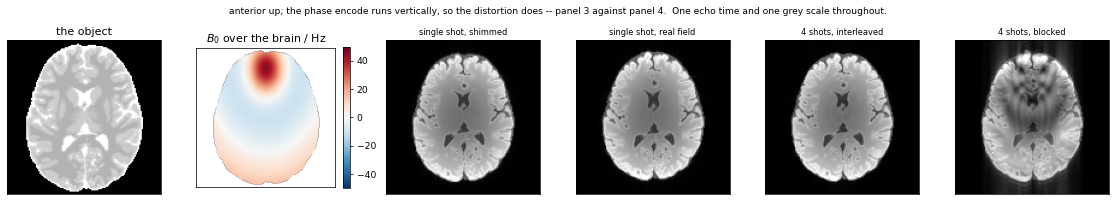

In [13]:
if brain_images:
    truth = ph.volume(matrix=NX).PD.numpy()[..., ph.slices_of(NZ, Z_CENTER)][:, :, NZ // 2]
    fig, axes = plt.subplots(1, 6, figsize=(17.0, 3.2))
    # A reconstruction is [ky, kx] = [y, x] and needs **no transform**: y is anterior-posterior
    # here, so it is already a conventional axial slice.  A phantom map is [x, y] and needs the
    # one transpose `same_frame` does.  `origin='lower'` is the other half of the convention and
    # the half that is easy to leave out -- matplotlib puts row zero at the top and row zero is
    # the most posterior line, so without it the frontal lobe comes out at the bottom.  Every
    # example in this repository draws this way.
    axes[0].imshow(ph.same_frame(truth), cmap='gray', origin='lower')
    axes[0].set(title='the object')
    field = axes[1].imshow(ph.same_frame(np.where(BRAIN, FIELD_HZ, np.nan)[:, :, NZ // 2]),
                           cmap='RdBu_r', vmin=-50, vmax=50, origin='lower')
    axes[1].set(title='$B_0$ over the brain / Hz')
    plt.colorbar(field, ax=axes[1], fraction=0.046)
    # One intensity scale across every panel.  Letting each autoscale is what makes a figure of
    # this kind lie: the distorted acquisitions pile signal into a few bright pixels, so their own
    # maxima are higher and the *brain* in them is drawn darker than the brain beside it.
    # **One scale across the whole figure**, which is what `01` §8 buys: every one of these files
    # is written at the same echo time, the same flip and the same TR, with the same run-in, so
    # they sit at the same point of the same steady state.  Letting the panels differ in contrast
    # and then sharing a ceiling is the version of this figure that lies -- the reader compares
    # two weightings and calls it an acquisition difference.
    ceiling = max(float(np.percentile(image, 99.5)) for image in brain_images.values())
    ceilings = {label: ceiling for label in brain_images}
    body = brain_images['single shot, shimmed'] > 0.1 * brain_images['single shot, shimmed'].max()
    kept = (brain_images['single shot, real field'][body].sum()
            / brain_images['single shot, shimmed'][body].sum())
    print(f'the distorted acquisition keeps {kept:.2f}x the signal of the shimmed one.')
    print('Essentially all of it, and that is a statement about this map rather than about EPI.')
    print('Off-resonance along ky is a **displacement**: it moves signal between voxels rather')
    print('than destroying it, so the panel below differs from its neighbour in *geometry* and')
    print('barely at all in brightness.')
    print()
    print('Signal is only lost when the field varies enough **within one voxel** to dephase it,')
    print('and this map is two smooth Lorentzians -- it has no gradient that steep anywhere, so')
    print(f'{1 - kept:.0%} goes missing.  Dropout of the kind an EPI is known for needs a sharp')
    print('source, an air cavity a few millimetres across, and there is not one in this phantom.')
    print('Worth knowing before reading the picture as a clean bill of health: what is shown here')
    print('is the distortion a well-shimmed head gives, not the worst an EPI can do.')
    for ax, (label, image) in zip(axes[2:], brain_images.items()):
        ax.imshow(image, cmap='gray', vmin=0.0, vmax=ceilings[label], origin='lower')
        ax.set_title(label, fontsize=9)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle('anterior up; the phase encode runs vertically, so the distortion does -- '
                 'panel 3 against panel 4.  One echo time and one grey scale throughout.',
                 fontsize=10)
    fig.tight_layout()

---
## 7. GRAPPA, and what a separately acquired calibration costs

Parallel imaging is the one part of this notebook that **cannot** be measured on one spin: it is a
statement about receive sensitivity, so it needs coils and an object.

[`01`](01_build.ipynb) §4 acquires the calibration band as **Cartesian reference lines** — one
line per excitation, on the EPI's own readout lobe, at a small flip angle and the shortest echo
time that lobe allows — rather than as segmented EPI shots. The reasoning is there. What is
measurable *here* is the price of acquiring the band separately at all, against a calibration
that no real scan can have.

It also needs **two** metrics, because one of them answers the wrong question:

| | what it measures | how |
|---|---|---|
| **retrospectively** | the *kernel* | one acquisition, undersampled afterwards, calibration taken from itself. Every acquisition difference is removed, so this is the unfolding alone |
| **on held-out data** | the *calibration* | both weight sets applied to one fully sampled dataset, against one truth -- the only comparison in which nothing but the calibration differs |

The prospective one cannot be an image difference against a fully sampled scan, and the reason is
worth stating plainly: **an accelerated EPI's k-space is not a subset of any fully sampled one.**
`R` changes the echo spacing, the train length and the `ky`-versus-time slope as well as removing
lines, so a difference image measures those instead of measuring the unfolding.

In [14]:
def grappa_fill(grid, calib, *, kernel_size=(5, 5), lamda=0.01):
    """Fill the unsampled lines with `pygrappa`, which is the part nobody should write twice."""
    from pygrappa import grappa as _grappa

    filled = _grappa(np.ascontiguousarray(grid.transpose(2, 1, 0)),
                     np.ascontiguousarray(calib.transpose(2, 1, 0)),
                     kernel_size=kernel_size, coil_axis=-1, lamda=lamda)
    return np.ascontiguousarray(np.asarray(filled).transpose(2, 1, 0))


def assemble_plan(raw, plan, made):
    """Split the raw readouts by a shot plan, regrid each, and hand back the band and the grid.

    A plan entry is ``(kind, lines)`` with `kind` in ``{'ref', 'img'}``.  The reference lines are
    one readout each and the imaging shot is a train, but both are regridded by the same operator,
    because both were played with the same readout lobe -- which is the point of acquiring them
    that way.
    """
    acs_rows, grid, row = {}, np.zeros((N_COILS, NY, NX), np.complex64), 0
    for kind, table in plan:
        block = raw[row:row + len(table)]
        row += len(table)
        per_coil = np.stack([regrid(block[:, :, c], made, reversed_flags(made, table))[0]
                             for c in range(N_COILS)])
        if kind == 'ref':
            for j, line in enumerate(table):
                acs_rows[line] = per_coil[:, j]
        else:
            grid[:, list(table)] = per_coil
    band = np.stack([acs_rows[line] for line in sorted(acs_rows)], axis=1) if acs_rows else None
    return band, grid


REFERENCE_LINES = [int(v) for v in nominal['reference_lines']]
FIRST_ACS = REFERENCE_LINES[0]

if BRAIN_IMAGES:
    began = time.perf_counter()
    raw = simulate('gre_epi_single', brain(0.0))
    full_grid = np.stack([regrid(raw[:, :, c], epi, flags)[0] for c in range(N_COILS)])
    reference = rss(ifft2c(full_grid))

    print('retrospective -- one acquisition, undersampled afterwards, calibration from itself')
    print(f'{"R":>3s} {"zero filled":>13s} {"GRAPPA":>9s}')
    for r in (3, 4):
        table = [int(v) for v in nominal[f'r{r}_lines']]
        under = np.zeros_like(full_grid)
        under[:, table] = full_grid[:, table]
        filled = grappa_fill(under, full_grid[:, FIRST_ACS:FIRST_ACS + ACS_LINES])
        errs = []
        for image in (rss(ifft2c(under)), rss(ifft2c(filled))):
            scale = (image * reference).sum() / (image ** 2).sum()
            errs.append(np.linalg.norm(image * scale - reference) / np.linalg.norm(reference))
        print(f'{r:3d} {errs[0]:12.4f} {errs[1]:9.4f}')
    print('The unfolding on its own, and the only like-for-like comparison here: both images come')
    print(f'from one acquisition.  ({time.perf_counter() - began:.0f} s)\n')

retrospective -- one acquisition, undersampled afterwards, calibration from itself
  R   zero filled    GRAPPA
  3       0.5195    0.0107


  4       0.5527    0.0356
The unfolding on its own, and the only like-for-like comparison here: both images come
from one acquisition.  (14 s)



### Two calibrations, one held-out dataset

The obvious comparison — reconstruct the accelerated scan and see how close it is to a fully
sampled one — **does not work, and it is worth saying why.** An accelerated EPI's k-space is not
a subset of any fully sampled one: `R` changes the echo spacing, the train length and the
`ky`-versus-time slope. An error against an `R = 1` image is dominated by that acquisition
difference, so it grades the contrast rather than the unfolding. A first draft measured exactly
that and drew the wrong conclusion from it.

The clean test holds the data fixed and varies only the weights:

1. take the **fully sampled** acquisition, which has a truth;
2. undersample it by `R`;
3. fill it with weights from the **acquired** GRE reference band, and again with weights taken
   from the fully sampled data's **own** centre — a self-calibration no real scan can have,
   because it is fitted on the very data it is then used to fill;
4. compare both to the same truth.

Identical data, identical truth, and the only difference is where the kernel was fitted. The
self-calibration is the ceiling; the gap to it is everything a separately acquired band brings
with it — its own excitation, its own steady state and its own echo time. The 60 Hz rows test
the fourth thing a reader expects to be in that list, **its own displacement**, and that one does
not survive the measurement.

In [15]:
if BRAIN_IMAGES:
    began = time.perf_counter()
    calibrations = {}
    for r in (3, 4):
        table = [int(v) for v in nominal[f'r{r}_lines']]
        made = readout(blip_lines=r)
        # The order `01` writes: the calibration prescan, then the imaging shot.  That shot
        # carries the same run-in every other file gets, which is what makes it comparable with
        # the fully sampled one and what makes its position in the file not matter.
        plan = [('ref', [line]) for line in REFERENCE_LINES] + [('img', table)]
        for offset_hz in (0.0, 60.0):
            field = 0.0 if offset_hz == 0 else np.full((NX, NX, NZ), offset_hz, np.float32)
            band_data, grid_r = assemble_plan(simulate(f'gre_epi_r{r}', brain(field)), plan, made)
            calibrations[(r, offset_hz)] = (band_data, grid_r)

    # The ceiling: the fully sampled data's own centre, fitted on the very lines it then fills.
    # No acquisition can reach it, which is what makes it the right thing to measure against.
    self_band = full_grid[:, FIRST_ACS:FIRST_ACS + ACS_LINES]

    def held_out(r, band):
        table = [int(v) for v in nominal[f'r{r}_lines']]
        under = np.zeros_like(full_grid)
        under[:, table] = full_grid[:, table]
        image = rss(ifft2c(grappa_fill(under, band)))
        scale = (image * reference).sum() / (image ** 2).sum()
        return float(np.linalg.norm(image * scale - reference) / np.linalg.norm(reference))

    print('the weights, on held-out fully sampled data')
    print(f'{"R":>3s} {"calibration":>20s} {"B0":>7s} {"relative error":>15s}')
    scores = {}
    for r in (3, 4):
        scores[(r, 'self')] = held_out(r, self_band)
        print(f'{r:3d} {"self-calibrated":>20s} {"--":>9s} {scores[(r, "self")]:15.4f}')
        for offset_hz in (0.0, 60.0):
            band_data, _ = calibrations[(r, offset_hz)]
            scores[(r, offset_hz)] = held_out(r, band_data)
            print(f'{r:3d} {"acquired GRE band":>20s} {offset_hz:6.0f}Hz '
                  f'{scores[(r, offset_hz)]:15.4f}')

    print()
    print(f'A separately acquired band costs '
          f'{scores[(3, 0.0)] / scores[(3, "self")]:.2f}x the self-calibrated error at R = 3 and '
          f'{scores[(4, 0.0)] / scores[(4, "self")]:.2f}x at R = 4,')
    print('on a shimmed object where the band and the imaging data are geometrically identical.')
    print('That gap is what the band brings with it and nothing else -- its own excitation, its')
    print('own steady state and its own echo time -- and it is the price of not being able to')
    print('calibrate on the data you are filling.  It is smaller at R = 4 only because the')
    print('baseline it is measured against is three times larger.')
    print()
    _esp_r3 = float(nominal['esp_r3'])
    _n_r3 = len(nominal['r3_lines'])
    print(f'Off-resonance costs the band '
          f'{scores[(3, 60.0)] / scores[(3, 0.0)]:.2f}x at R = 3 and '
          f'{scores[(4, 60.0)] / scores[(4, 0.0)]:.2f}x at R = 4 -- which is to say nothing at')
    print('all, and this is the one number in the section worth being surprised by.  The prediction')
    print('was that a reference line is displaced by off-resonance too, so it must carry some of')
    print('the distortion it is meant to be free of.  It does, and the amount is negligible:')
    print('displacement follows the time from excitation, so at 60 Hz the band moves')
    print(f'{60.0 * _esp_r3:.2f} px -- one echo spacing -- against the {60.0 * _n_r3 * _esp_r3:.1f} '
          f'px the R = 3 imaging shot moves.')
    print('A whole train is what makes an EPI distort; one lobe is a Cartesian gradient echo.')
    print()
    print(f'The acceleration itself is the larger cost by far: R = 4 leaves '
          f'{scores[(4, "self")] / scores[(3, "self")]:.2f}x the error of R = 3 even')
    print(f'with the unbeatable calibration.  ({time.perf_counter() - began:.0f} s)')

the weights, on held-out fully sampled data
  R          calibration      B0  relative error
  3      self-calibrated        --          0.0107


  3    acquired GRE band      0Hz          0.0126
  3    acquired GRE band     60Hz          0.0127


  4      self-calibrated        --          0.0356
  4    acquired GRE band      0Hz          0.0380


  4    acquired GRE band     60Hz          0.0381

A separately acquired band costs 1.18x the self-calibrated error at R = 3 and 1.07x at R = 4,
on a shimmed object where the band and the imaging data are geometrically identical.
That gap is what the band brings with it and nothing else -- its own excitation, its
own steady state and its own echo time -- and it is the price of not being able to
calibrate on the data you are filling.  It is smaller at R = 4 only because the
baseline it is measured against is three times larger.

Off-resonance costs the band 1.00x at R = 3 and 1.00x at R = 4 -- which is to say nothing at
all, and this is the one number in the section worth being surprised by.  The prediction
was that a reference line is displaced by off-resonance too, so it must carry some of
the distortion it is meant to be free of.  It does, and the amount is negligible:
displacement follows the time from excitation, so at 60 Hz the band moves
0.04 px -- one echo spacing -- against the

### And the scan itself

The accelerated files reconstructed with their own calibration, beside the fully sampled
acquisition. These are *images*, not a metric — §7's number is the cell above, for the reason
that cell gives.

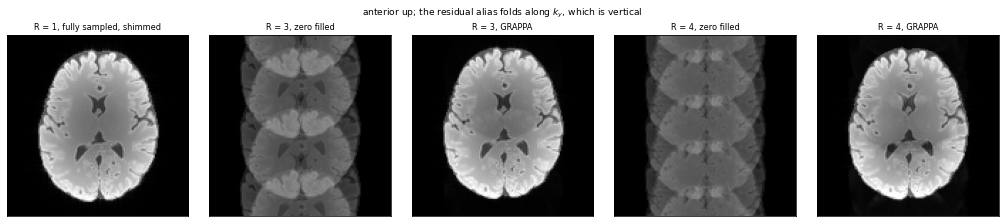

In [16]:
if BRAIN_IMAGES:
    shown = {}
    for (r, offset_hz), (band_data, grid_r) in calibrations.items():
        if offset_hz != 60.0:
            continue
        shown[f'R = {r}, zero filled'] = rss(ifft2c(grid_r))
        shown[f'R = {r}, GRAPPA'] = rss(ifft2c(grappa_fill(grid_r, band_data)))

    order = ['R = 3, zero filled', 'R = 3, GRAPPA',
             'R = 4, zero filled', 'R = 4, GRAPPA']
    fig, axes = plt.subplots(1, len(order) + 1, figsize=(3.1 * len(order) + 3.1, 3.4))
    # One ceiling across all five.  The accelerated files carry the same echo time, flip, TR and
    # run-in as the fully sampled one -- `01` section 8 checks that and prints the residual
    # spread -- so the R = 1 panel is a like-for-like reference rather than a differently
    # weighted picture that happens to be standing beside them.
    ceiling = max(float(np.percentile(image, 99.5))
                  for image in [reference, *(shown[label] for label in order)])
    axes[0].imshow((reference), cmap='gray', origin='lower', vmin=0.0, vmax=ceiling)
    axes[0].set_title('R = 1, fully sampled, shimmed', fontsize=9)
    for ax, label in zip(axes[1:], order):
        ax.imshow((shown[label]), cmap='gray', vmin=0.0, vmax=ceiling, origin='lower')
        ax.set_title(label, fontsize=9)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle('anterior up; the residual alias folds along $k_y$, which is vertical',
                 fontsize=10)
    fig.tight_layout()

---
## 8. The transient, and why a segmented EPI is not four single-shot EPIs

Three files acquire the **same four interleaved shots** of the same 128 lines, with the same
gradients and the same echo time. They differ only in what happens to the magnetisation between
the shots:

| | TR | run-in | RF spoiling |
|---|---|---|---|
| `gre_epi_4shot_naive` | 200 ms | 1 shot | none — a fixed carrier phase |
| `gre_epi_4shot_tr1s` | 1 s | 1 shot | none |
| `gre_epi_4shot` | 1 s | 2 shots | 117° per excitation |

The brain is **shimmed** here, so nothing below is off-resonance, and all three share an
ordering, so nothing below is §5 either.

> An interleaved table puts consecutive `ky` lines in **different shots**. So any shot-to-shot
> difference in signal is a modulation of period 4 along `ky`, and a period-4 modulation is a
> replica of the object at `Ny/4` — 32 pixels. It reads as an under-sampling artefact and has
> nothing to do with sampling.

[`01`](01_build.ipynb) §8 gives the mechanism as one number: `exp(-TR/T2)` is the transverse
magnetisation that survives to the next excitation for the gradient spoiler to finish off, and
it is **8.2%** at 200 ms against 4e-6 at 1 s. A perfectly spoiled 90° excitation reaches its
steady state in one TR whatever the TR is; 8.2% of carry-over is what turns that into a
transient several shots long, and four shots sampling four different points of it is the
replica below.

In [17]:
if BRAIN_IMAGES:
    began = time.perf_counter()
    FOUR = [[int(v) for v in seg] for seg in nominal['four_shot']]
    made_4 = readout(blip_lines=4)

    def assemble_coils(raw, shots, made):
        """Regrid every coil of every shot and place it, and report each shot's mean signal."""
        grid, row, per_shot = np.zeros((N_COILS, NY, NX), np.complex64), 0, []
        for table in shots:
            block = raw[row:row + len(table)]
            row += len(table)
            per_shot.append(float(np.abs(block[:, :, 0]).mean()))
            flags_r = reversed_flags(made, table)
            grid[:, list(table)] = np.stack([regrid(block[:, :, c], made, flags_r)[0]
                                             for c in range(N_COILS)])
        return grid, np.array(per_shot)

    def replica_ratio(image, offset):
        """Mean signal where the object would land if displaced by `offset`, over the object."""
        body = image > 0.1 * image.max()
        fold = (~body) & (np.roll(body, offset, axis=0) | np.roll(body, -offset, axis=0))
        return float(image[fold].mean() / image[body].mean())

    STEPS = [('gre_epi_4shot_naive', 'TR 200 ms, 1 dummy, no spoiling'),
             ('gre_epi_4shot_tr1s', 'TR 1 s, 1 dummy, no spoiling'),
             ('gre_epi_4shot', 'TR 1 s, 2 dummies, spoiled')]
    transient, ghosts = {}, {}
    print(f'{"file":22s} {"per-shot signal":>30s} {"spread":>8s} {"replica at Ny/4":>17s}')
    for name, _ in STEPS:
        grid_4, per_shot = assemble_coils(simulate(name, brain(0.0)), FOUR, made_4)
        transient[name] = rss(ifft2c(grid_4))
        ghosts[name] = replica_ratio(transient[name], NY // 4)
        spread = (per_shot.max() - per_shot.min()) / per_shot.mean()
        print(f'{name:22s} {str([round(float(v), 2) for v in per_shot]):>30s} {spread:7.1%} '
              f'{ghosts[name]:17.4f}')

    _naive, _tr1s, _fixed = (ghosts[name] for name, _ in STEPS)
    print()
    print(f'The TR alone is worth {_naive / _tr1s:.1f}x and the run-in and spoiling together '
          f'{_tr1s / _fixed:.1f}x more,')
    print(f'for {_naive / _fixed:.1f}x in total -- on a shimmed object, at the same lines in the '
          f'same four')
    print('shots at the same echo time.  The per-shot column is the mechanism rather than the')
    print('symptom: in the first file the four shots disagree by more than their own mean, and')
    print('they do not disagree *monotonically*, which is what rules out a plain T1 run-in and')
    print('points at the coherences the spoiler is leaving behind.')
    print()
    print()
    print('RF spoiling is not separated from the run-in here: at a 1 s TR there is 4e-6 of')
    print('transverse magnetisation for it to act on.  `01` section 8 is why it is in the')
    print('sequence regardless, and why `EPI2D.build` had to grow a phase_deg for it to be.')
    print(f'({time.perf_counter() - began:.0f} s)')

file                                  per-shot signal   spread   replica at Ny/4


gre_epi_4shot_naive            [1.0, 0.5, 1.91, 2.43]  132.4%            0.1499


gre_epi_4shot_tr1s           [2.38, 1.86, 2.03, 2.26]   24.1%            0.0377


gre_epi_4shot                 [2.2, 1.86, 2.03, 2.26]   19.2%            0.0156

The TR alone is worth 4.0x and the run-in and spoiling together 2.4x more,
for 9.6x in total -- on a shimmed object, at the same lines in the same four
shots at the same echo time.  The per-shot column is the mechanism rather than the
symptom: in the first file the four shots disagree by more than their own mean, and
they do not disagree *monotonically*, which is what rules out a plain T1 run-in and
points at the coherences the spoiler is leaving behind.


RF spoiling is not separated from the run-in here: at a 1 s TR there is 4e-6 of
transverse magnetisation for it to act on.  `01` section 8 is why it is in the
sequence regardless, and why `EPI2D.build` had to grow a phase_deg for it to be.
(39 s)


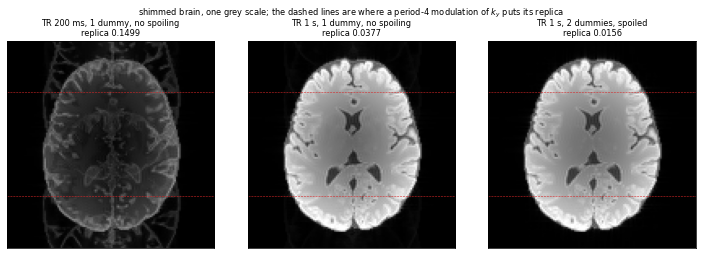

In [18]:
if BRAIN_IMAGES:
    fig, axes = plt.subplots(1, len(STEPS), figsize=(3.7 * len(STEPS), 3.9))
    ceiling = max(float(np.percentile(v, 99.5)) for v in transient.values())
    for ax, (name, title) in zip(axes, STEPS):
        ax.imshow(transient[name], cmap='gray', origin='lower', vmin=0.0, vmax=ceiling)
        ax.axhline(NY // 2 + NY // 4, color='C3', lw=0.6, ls='--')
        ax.axhline(NY // 2 - NY // 4, color='C3', lw=0.6, ls='--')
        ax.set_title(f'{title}\nreplica {ghosts[name]:.4f}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle('shimmed brain, one grey scale; the dashed lines are where a period-4 modulation '
                 'of $k_y$ puts its replica', fontsize=9)
    fig.tight_layout()

---
## What this notebook measured

| | |
|---|---|
| **the readout bandwidth is over a hundred times the phase-encode one** | so an EPI is effectively immune along `kx` and distorts along `ky`, and every artefact below is that ratio being large |
| **the sampling question comes before the interpolation question** | at `oversampling=1` the worst gap is above one Δk and *every* method fails, including on the band-limited object. No interpolator recovers what was never measured |
| **once the sampling is adequate, scipy wins** | including against the least-squares sinc that is supposed to be optimal for a band-limited object — so the interpolation is not written here, only the operator around it |
| **the matrix *is* scipy** | to 1e-15, and 15× faster to apply because it does not depend on the data |
| **forgetting to reverse is a mirror; skipping the regridding is not a ghost** | the second is the same error on every echo, so it is a geometric compression rather than a replica — which is the half a reader expects to come out the other way |
| **off-resonance shifts along `ky` exactly as `Δf·Ny·esp` predicts** | and modulates `kx` with period two, which is the N/2 replica |
| **the odd/even phase is a ramp in `kx`, and its dual is a ramp in `x`** | a `.seq` carries no gradient delay, so only the first is here — and fitting the wrong one does nothing at all |
| **the ordering alone moves the ghost several-fold** | at the same lines, the same shots and the same off-resonance. Interleaving leaves a sawtooth of period 4; blocking leaves one of period 32 |
| **GRAPPA needs two metrics** | the kernel alone is measured retrospectively; the scan is judged by the alias it leaves, because an accelerated EPI's k-space is not a subset of any fully sampled one |
| **a separately acquired calibration band costs 1.18× a self-calibration no scan can have** | and the term the argument predicted — that the band is displaced by off-resonance too — costs 1.00×, because displacement follows the *time from excitation* and one lobe is 0.04 px where the train is 1.9 |
| **a segmented EPI acquired before its steady state puts a replica at `Ny/4`** | which looks exactly like an under-sampling artefact and is not one. `exp(-TR/T2)` is the whole mechanism: 8.2% of carry-over at a 200 ms TR, 4e-6 at 1 s, and 9.5× between the two ends of the decomposition |
| **every panel in this notebook is at one echo time, one flip, one TR and one run-in** | so a difference between two of them is the acquisition being compared. Getting that wrong is the failure mode of a figure like §6's: the reader sees two contrasts and reads an artefact |

Next: [`../se_epi_2d/02_simulate_and_reconstruct.ipynb`](../se_epi_2d/02_simulate_and_reconstruct.ipynb)
asks whether a refocusing pulse fixes any of it. It fixes exactly one thing, and it is not the one
most readers expect.